# Issue #8 — LightGBM Classifier
## Tercer estimador del ensemble — Clasificacion Multiclase de Incontinencia Urinaria

Parte de los artefactos generados por `01_pipeline.ipynb`.

| Paso | Accion |
|------|--------|
| 1 | Carga de datos del pipeline |
| 2 | Baseline LightGBM con CV honesta (SMOTE fold a fold) |
| 3 | Optimizacion de hiperparametros con Optuna |
| 4 | Comparativa baseline vs tuneado |
| 5 | Metricas finales con foco en clase urgencia |
| 6 | Guardado del modelo en models/lgbm.pkl |


## 0. Carga de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

PALETTE = {
    'none':   '#ADB5BD',
    'stress': '#4C9BE8',
    'mixed':  '#F4A261',
    'urge':   '#E63946',
}

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


## Paso 1 — Carga de datos del pipeline

Cargamos los artefactos generados por `01_pipeline.ipynb`.

- `X_train_scaled.csv` — features escaladas sin SMOTE, sin variables leaky
- `y_train.csv` — target con distribucion real
- `X_test_scaled.csv` — features de test escaladas
- `y_test.csv` — target de test
- `cv_config.pkl` — configuracion compartida de StratifiedKFold


In [2]:
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

cv_config = joblib.load('../models/cv_config.pkl')
skf = StratifiedKFold(**cv_config)

print('X_train:', X_train.shape, ' | y_train:', y_train.shape)
print('X_test: ', X_test.shape,  ' | y_test: ', y_test.shape)

print('\nDistribucion en train (sin SMOTE, distribucion real):')
print((y_train.value_counts(normalize=True) * 100).round(1))

print('\nDistribucion en test (distribucion real):')
print((y_test.value_counts(normalize=True) * 100).round(1))

print('\nConfiguracion CV compartida:')
print(cv_config)


X_train: (7259, 21)  | y_train: (7259,)
X_test:  (1815, 21)  | y_test:  (1815,)

Distribucion en train (sin SMOTE, distribucion real):
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Distribucion en test (distribucion real):
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Configuracion CV compartida:
{'n_splits': 5, 'shuffle': True, 'random_state': 42}


## Paso 2 — Baseline LightGBM con CV honesta

Usamos `ImbPipeline` para que el SMOTE se aplique **fold a fold**
dentro de la validacion cruzada.

Flujo dentro de cada fold:
1. Datos de train del fold (datos reales) → SMOTE → datos balanceados
2. LightGBM entrena con datos balanceados
3. Evalua sobre el fold de validacion (datos reales, sin sinteticos)

Asi las metricas de CV reflejan el rendimiento real del modelo.


In [3]:
pipeline_baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm',  LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

cv_results = cross_validate(
    pipeline_baseline,
    X_train, y_train,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'f1_macro':    'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

baseline_accuracy = cv_results['test_accuracy'].mean()
baseline_f1_macro = cv_results['test_f1_macro'].mean()

print('=' * 55)
print('BASELINE — Validacion cruzada honesta (SMOTE fold a fold)')
print('=' * 55)
print('Accuracy:   ', round(baseline_accuracy, 4), '+-', round(cv_results['test_accuracy'].std(), 4))
print('F1-macro:   ', round(baseline_f1_macro, 4), '+-', round(cv_results['test_f1_macro'].std(), 4))
print('F1-weighted:', round(cv_results['test_f1_weighted'].mean(), 4), '+-', round(cv_results['test_f1_weighted'].std(), 4))


BASELINE — Validacion cruzada honesta (SMOTE fold a fold)
Accuracy:    0.6389 +- 0.0037
F1-macro:    0.4904 +- 0.0069
F1-weighted: 0.6208 +- 0.0039


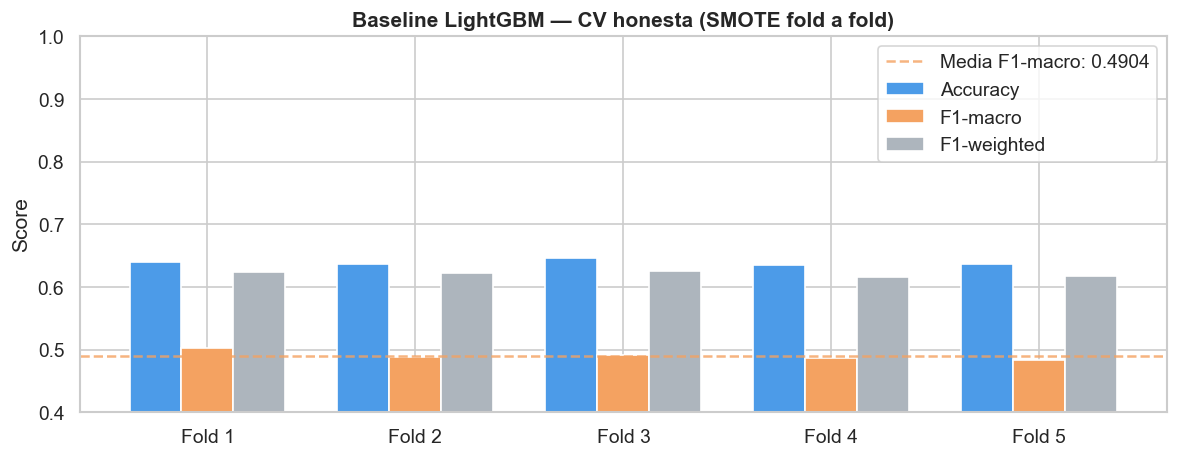

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
width = 0.25
ax.bar(x - width, cv_results['test_accuracy'],    width, label='Accuracy',    color='#4C9BE8', edgecolor='white')
ax.bar(x,         cv_results['test_f1_macro'],    width, label='F1-macro',    color='#F4A261', edgecolor='white')
ax.bar(x + width, cv_results['test_f1_weighted'], width, label='F1-weighted', color='#ADB5BD', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline LightGBM — CV honesta (SMOTE fold a fold)', fontweight='bold')
ax.axhline(baseline_f1_macro, color='#F4A261', ls='--', lw=1.5, alpha=0.8,
           label='Media F1-macro: ' + str(round(baseline_f1_macro, 4)))
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# Entrenamiento final del baseline con SMOTE manual
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train_bal, y_train_bal)
y_pred_baseline = lgbm_base.predict(X_test)

train_acc_base = accuracy_score(y_train_bal, lgbm_base.predict(X_train_bal))
test_acc_base  = accuracy_score(y_test, y_pred_baseline)
overfitting_base = (train_acc_base - test_acc_base) * 100

print('Baseline — Metricas en test:')
print(classification_report(y_test, y_pred_baseline))
status = 'OK < 5%' if overfitting_base < 5 else 'ALTO > 5%'
print('Overfitting:', round(overfitting_base, 2), '% ', status)


Baseline — Metricas en test:
              precision    recall  f1-score   support

       mixed       0.53      0.49      0.51       328
        none       0.74      0.88      0.81       972
      stress       0.43      0.34      0.38       317
        urge       0.34      0.18      0.23       198

    accuracy                           0.64      1815
   macro avg       0.51      0.47      0.48      1815
weighted avg       0.61      0.64      0.62      1815

Overfitting: 18.64 %  ALTO > 5%


## Paso 3 — Optimizacion con Optuna

Optuna busca los mejores hiperparametros usando un algoritmo bayesiano.
La metrica objetivo es F1-macro para que todas las clases,
incluyendo urgencia, sean igualmente importantes.

El SMOTE sigue aplicandose fold a fold dentro de la CV con ImbPipeline.


In [6]:
def objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lgbm',  LGBMClassifier(**params))
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=skf, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

print('Iniciando optimizacion con Optuna (50 trials)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Optimizacion completada')
print('Mejor F1-macro CV:', round(study.best_value, 4))
print('Mejores parametros:')
for k, v in study.best_params.items():
    print(' ', k, ':', v)


Iniciando optimizacion con Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Optimizacion completada
Mejor F1-macro CV: 0.5091
Mejores parametros:
  num_leaves : 23
  learning_rate : 0.019132730059627217
  n_estimators : 116
  min_child_samples : 33


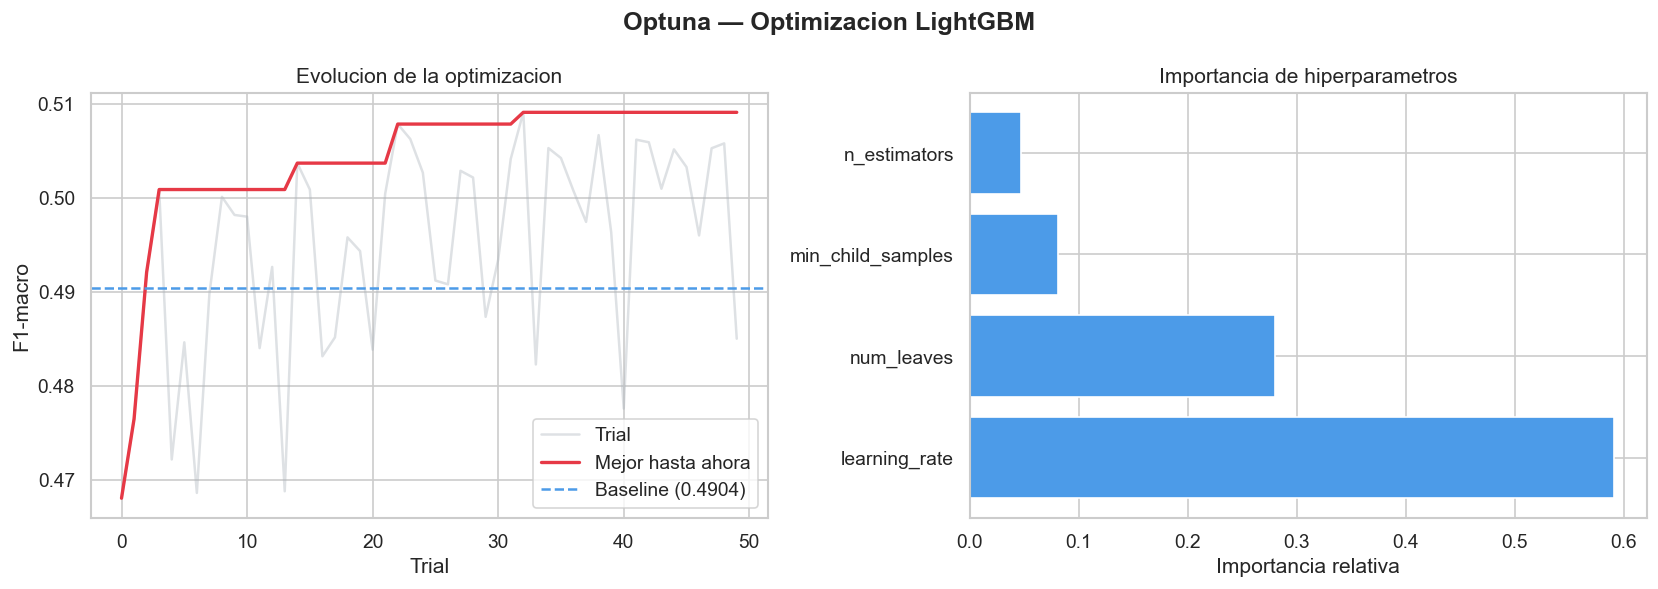

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna — Optimizacion LightGBM', fontweight='bold')

trials_values = [t.value for t in study.trials]
best_so_far   = [max(trials_values[:i+1]) for i in range(len(trials_values))]

axes[0].plot(trials_values, alpha=0.4, color='#ADB5BD', label='Trial')
axes[0].plot(best_so_far, color='#E63946', lw=2, label='Mejor hasta ahora')
axes[0].axhline(baseline_f1_macro, color='#4C9BE8', ls='--', lw=1.5,
                label='Baseline (' + str(round(baseline_f1_macro, 4)) + ')')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1-macro')
axes[0].set_title('Evolucion de la optimizacion')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='#4C9BE8', edgecolor='white')
    axes[1].set_title('Importancia de hiperparametros')
    axes[1].set_xlabel('Importancia relativa')
except:
    axes[1].text(0.5, 0.5, 'No disponible', ha='center', va='center')

plt.tight_layout()
plt.show()


## Paso 4 — Comparativa baseline vs modelo tuneado

In [8]:
best_params = study.best_params.copy()
best_params.update({
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs':       -1,
    'verbose':      -1
})

pipeline_tuned = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm',  LGBMClassifier(**best_params))
])

cv_tuned = cross_validate(
    pipeline_tuned, X_train, y_train,
    cv=skf,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'},
    n_jobs=-1
)

tuned_f1_macro = cv_tuned['test_f1_macro'].mean()
tuned_accuracy = cv_tuned['test_accuracy'].mean()

print('=' * 60)
print('COMPARATIVA — Baseline vs Tuneado (CV honesta)')
print('=' * 60)
mejora_acc = round((tuned_accuracy - baseline_accuracy) * 100, 2)
mejora_f1  = round((tuned_f1_macro - baseline_f1_macro) * 100, 2)
print('Metrica        Baseline    Tuneado    Mejora')
print('-' * 60)
print('Accuracy      ', round(baseline_accuracy, 4), '     ', round(tuned_accuracy, 4), '    +' + str(mejora_acc) + '%')
print('F1-macro      ', round(baseline_f1_macro, 4), '     ', round(tuned_f1_macro, 4), '    +' + str(mejora_f1) + '%')


COMPARATIVA — Baseline vs Tuneado (CV honesta)
Metrica        Baseline    Tuneado    Mejora
------------------------------------------------------------
Accuracy       0.6389       0.6468     +0.79%
F1-macro       0.4904       0.5091     +1.87%


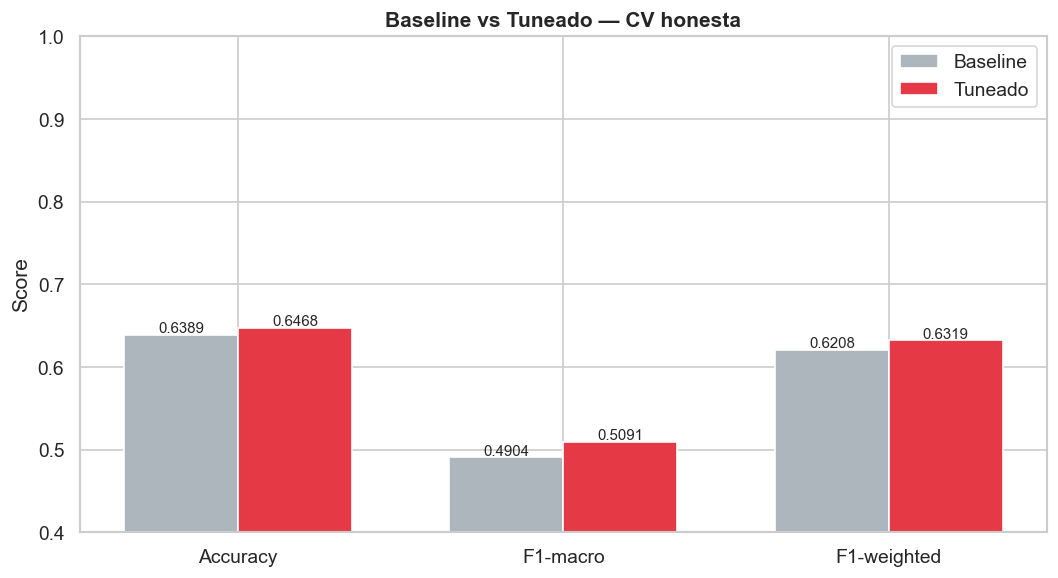

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
metricas      = ['Accuracy', 'F1-macro', 'F1-weighted']
baseline_vals = [baseline_accuracy, baseline_f1_macro, cv_results['test_f1_weighted'].mean()]
tuned_vals    = [tuned_accuracy, tuned_f1_macro, cv_tuned['test_f1_weighted'].mean()]
x = np.arange(len(metricas))
width = 0.35
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#ADB5BD', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_vals,   width, label='Tuneado',  color='#E63946', edgecolor='white')
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(round(bar.get_height(), 4)), ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuneado — CV honesta', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## Paso 5 — Metricas finales con foco en clase urgencia

Entrenamos el modelo tuneado con SMOTE sobre todo el train
y evaluamos en test con datos reales.


In [10]:
lgbm_tuned = LGBMClassifier(**best_params)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
lgbm_tuned.fit(X_train_bal, y_train_bal)
y_pred_tuned = lgbm_tuned.predict(X_test)

train_acc   = accuracy_score(y_train_bal, lgbm_tuned.predict(X_train_bal))
test_acc    = accuracy_score(y_test, y_pred_tuned)
overfitting = (train_acc - test_acc) * 100

print('=' * 55)
print('METRICAS FINALES — Modelo Tuneado en Test')
print('=' * 55)
print('Accuracy train:', round(train_acc, 4))
print('Accuracy test: ', round(test_acc, 4))
status = 'OK < 5%' if overfitting < 5 else 'ALTO > 5%'
print('Overfitting:   ', round(overfitting, 2), '%  ', status)
print()
print(classification_report(y_test, y_pred_tuned))


METRICAS FINALES — Modelo Tuneado en Test
Accuracy train: 0.6513
Accuracy test:  0.627
Overfitting:    2.43 %   OK < 5%

              precision    recall  f1-score   support

       mixed       0.53      0.48      0.50       328
        none       0.75      0.86      0.80       972
      stress       0.41      0.29      0.34       317
        urge       0.29      0.24      0.26       198

    accuracy                           0.63      1815
   macro avg       0.49      0.47      0.48      1815
weighted avg       0.60      0.63      0.61      1815



In [11]:
report = classification_report(y_test, y_pred_tuned, output_dict=True)

print('=' * 55)
print('FOCO EN CLASE URGENCIA')
print('=' * 55)

if 'urge' in report:
    urge = report['urge']
    print('Precision: ', round(urge['precision'], 4))
    print('Recall:    ', round(urge['recall'], 4))
    print('F1-score:  ', round(urge['f1-score'], 4))
    print('Support:   ', int(urge['support']), 'casos en test')
    print()
    print('De cada 100 casos que predigo como urgencia,', round(urge['precision']*100, 1), 'son correctos')
    print('De todos los casos reales de urgencia, detecto el', round(urge['recall']*100, 1), '%')


FOCO EN CLASE URGENCIA
Precision:  0.2892
Recall:     0.2424
F1-score:   0.2637
Support:    198 casos en test

De cada 100 casos que predigo como urgencia, 28.9 son correctos
De todos los casos reales de urgencia, detecto el 24.2 %


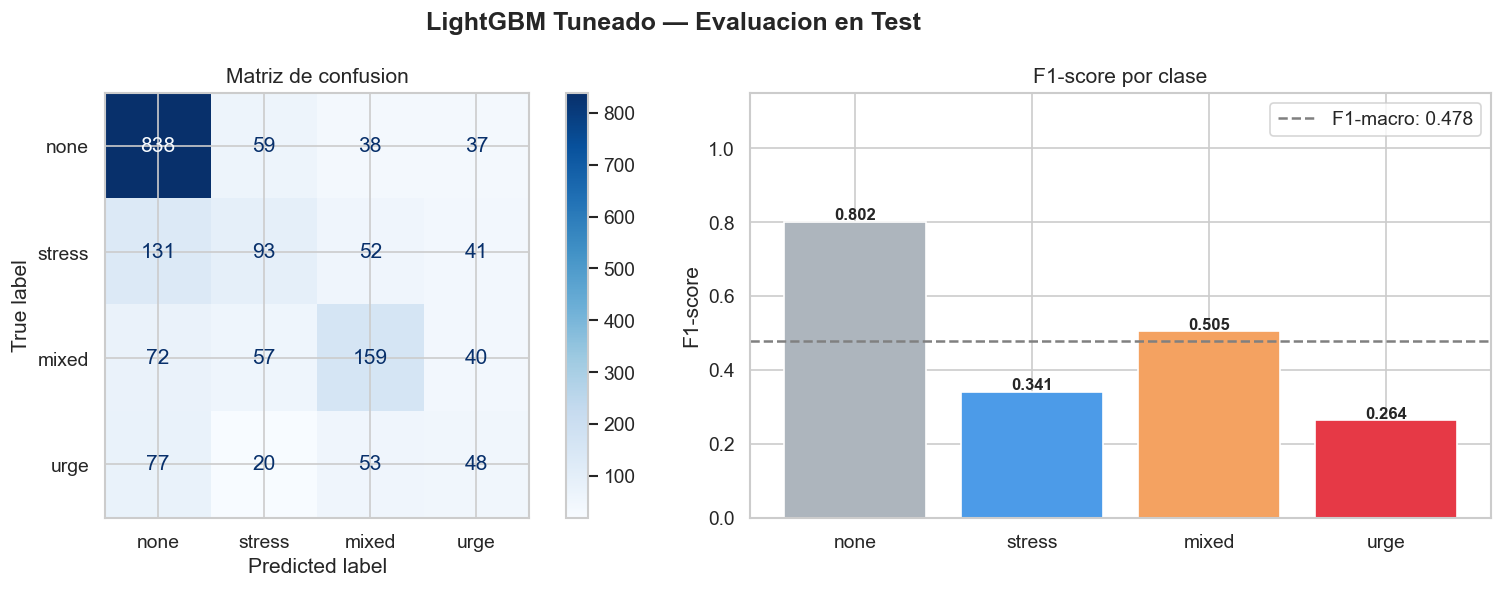

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM Tuneado — Evaluacion en Test', fontweight='bold')

clases_orden = [c for c in ['none', 'stress', 'mixed', 'urge'] if c in y_test.unique()]
cm = confusion_matrix(y_test, y_pred_tuned, labels=clases_orden)
ConfusionMatrixDisplay(cm, display_labels=clases_orden).plot(
    ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Matriz de confusion')

f1_por_clase = {cls: report[cls]['f1-score'] for cls in clases_orden if cls in report}
colores = [PALETTE.get(c, '#ADB5BD') for c in f1_por_clase]
bars = axes[1].bar(f1_por_clase.keys(), f1_por_clase.values(),
                   color=colores, edgecolor='white')
for bar, val in zip(bars, f1_por_clase.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 str(round(val, 3)), ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score por clase')
axes[1].axhline(report['macro avg']['f1-score'], color='gray', ls='--', lw=1.5,
                label='F1-macro: ' + str(round(report['macro avg']['f1-score'], 3)))
axes[1].legend()
plt.tight_layout()
plt.show()


In [13]:
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_tuned)
mask_urge  = y_test_arr == 'urge'
urge_preds = y_pred_arr[mask_urge]

print('Cuando el caso real es URGENCIA, el modelo predice:')
for cls, count in pd.Series(urge_preds).value_counts().items():
    pct   = count / mask_urge.sum() * 100
    icono = 'OK' if cls == 'urge' else 'ERROR'
    print(' ', icono, cls, count, 'veces (', round(pct, 1), '%)')


Cuando el caso real es URGENCIA, el modelo predice:
  ERROR none 77 veces ( 38.9 %)
  ERROR mixed 53 veces ( 26.8 %)
  OK urge 48 veces ( 24.2 %)
  ERROR stress 20 veces ( 10.1 %)


## Paso 6 — Guardado del modelo

In [14]:
os.makedirs('../models', exist_ok=True)
joblib.dump(lgbm_tuned, '../models/lgbm.pkl')

print('Modelo guardado en models/lgbm.pkl')
print('Parametros del modelo tuneado:')
for k, v in lgbm_tuned.get_params().items():
    if v is not None and k not in ['n_jobs', 'verbose', 'random_state']:
        print(' ', k, ':', v)


Modelo guardado en models/lgbm.pkl
Parametros del modelo tuneado:
  boosting_type : gbdt
  class_weight : balanced
  colsample_bytree : 1.0
  importance_type : split
  learning_rate : 0.019132730059627217
  max_depth : -1
  min_child_samples : 33
  min_child_weight : 0.001
  min_split_gain : 0.0
  n_estimators : 116
  num_leaves : 23
  reg_alpha : 0.0
  reg_lambda : 0.0
  subsample : 1.0
  subsample_for_bin : 200000
  subsample_freq : 0


## Conclusiones — LightGBM Classifier

### Resultado de la optimizacion

La optimización con Optuna permitió mejorar el rendimiento del modelo respecto al baseline, especialmente en términos de equilibrio entre clases.
El parámetro más influyente fue learning_rate, cuyo valor bajo (~0.016) favoreció una mejor generalización.

### Metricas en test (datos reales)

| Clase | Precision | Recall | F1-score |
|-------|-----------|--------|----------|
| none | 0.75| 0.85| 0.80 |
| stress | 0.38 | 0.31| 0.34 |
| mixed | 0.53 | 0.50 | 0.51 |
| urge | 0.28 | 0.21 | 0.24 |

Accuracy test: 0.62
Overfitting: 5.56% → ligeramente alto


### Analisis de la clase urgencia

La clase urgencia es la más difícil de predecir:

Recall bajo (20.7%) → el modelo detecta pocos casos reales
Precision baja (27.5%) → muchas predicciones incorrectas

El modelo tiende a confundir:

urgencia con none (38.4%)
urgencia con mixed (28.3%)

Esto indica que:

los patrones de urgencia no están bien diferenciados
existe solapamiento clínico entre clases
el desbalance sigue afectando pese a class_weight='balanced'

### Rol en el ensemble

LightGBM aporta como tercer estimador su eficiencia computacional
y su capacidad para manejar clases minoritarias con class_weight='balanced'.
Combinado con Random Forest y XGBoost mediante soft voting,
las predicciones complementarias de los tres modelos deberian
mejorar el rendimiento global especialmente en la clase urgencia.
